In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.stats as sps
from pathlib import Path
import os
import re
from glob import glob
import textwrap

In [2]:
from data_analysis import *
from data_extraction import *
from myprobs import *
from extracted_data_from_paper import *

$L=11mm$ experiment
$L=111mm$ experiment


In [3]:
# Use the below only once the plots are clearly done so it is ready for presentation style
# This cell was taken from gemini and modified accordingly
# import matplotlib as mpl

# mpl.use("pgf")
# latex_textwidth_inches = 5.9 
# plt.rcParams.update({
#     "pgf.texsystem": "pdflatex",   # or 'xelatex' / 'lualatex'
#     "text.usetex": True,           # use LaTeX to write all text
#     "font.family": "serif",        # use serif (matching LaTeX default)
#     "pgf.rcfonts": False,          # don't setup fonts from rc parameters
#     "font.size": 11,               # MATCH YOUR LATEX DOCUMENT FONT SIZE
#     "axes.labelsize": 11,          # Match LaTeX font size
#     "legend.fontsize": 9,          # Slightly smaller for legends
#     "xtick.labelsize": 9,          # Slightly smaller for ticks
#     "ytick.labelsize": 9,
#     # CRITICAL: Set figure width to match LaTeX text width!
#     "figure.figsize": (latex_textwidth_inches, 4) # (width, height)
# })

def configureLatexPlot(context="twocolumn", aspect_ratio=None, caption_spacer=0.7, column_size = None, bigger_font_by = 0):
    """
    Configures Matplotlib rcParams for perfect LaTeX exports.
    
    Parameters:
    context (str): 'article' (full width), 'twocolumn' (half width), or 'beamer' (slides)
    """
    
    # 1. Define dimensions and fonts based on standard LaTeX templates
    if context == "twocolumn":
        # Typical IEEE/ACM two-column format
        # \columnwidth is usually ~252pt (3.5 inches)
        fig_width = 3.5  
        fig_height = 2.5 
        base_font_size = 11 # Two-column papers usually use 9pt or 10pt base fonts
        
    elif context == "beamer":
        # Standard Beamer slide (4:3 aspect ratio)
        # \textwidth is usually ~307pt (4.25 inches)
        latex_width_pt  = 398.3386
        latex_height_pt = 233.74188
        latex_width_inch  = latex_width_pt/72.27
        latex_height_inch = latex_height_pt/72.27
        if column_size is not None:
            latex_width_inch *= column_size
        fig_width  = latex_width_inch#4.25 
        fig_height = latex_height_inch*caption_spacer # multiplier so i have space for the caption#2.75 
        base_font_size = 11 # Beamer fonts look big on screen, but base is 11pt
    
    elif context == "halfbeamer":
        # Standard Beamer slide (4:3 aspect ratio)
        # \textwidth is usually ~307pt (4.25 inches)
        latex_width_pt  = 398.3386/2
        latex_height_pt = 233.74188
        latex_width_inch  = latex_width_pt/72.27
        if column_size is not None:
            latex_width_inch *= column_size
        latex_height_inch = latex_height_pt/72.27
        fig_width  = latex_width_inch#4.25 
        fig_height = latex_height_inch*caption_spacer# multiplier so i have space for the caption #2.75 
        base_font_size = 11 # Beamer fonts look big on screen, but base is 11pt    
        # plt.rcParams.update({
        #     "legend.handlelength":1,
        #     "handletextpad":0.4,
        #     "borderpad":0.4
        #     # plt.legend(
        #     #     loc="upper left",
        #     #     fontsize=8, 
        #     #     handlelength=1.0, 
        #     #     handletextpad=0.4, 
        #     #     borderpad=0.4
        #     # )
        # })
    elif context == "article":
        # Standard single column (e.g., typical report/thesis)
        # \textwidth is usually ~426pt (5.9 inches)
        fig_width = 5.9  
        fig_height = 4.0 
        base_font_size = 11
        
    else:
        raise ValueError("Context must be 'article', 'twocolumn', 'halfbeamer', or 'beamer'")

    if aspect_ratio is not None:
        fig_height = fig_width/aspect_ratio
    
    # 2. Apply the settings globally
    base_font_size += bigger_font_by
    
    plt.rcParams.update({
        # "text.usetex": True,
        # "font.family": "serif",
        # "font.serif": ["Computer Modern Roman"], 
        
        # Scaling everything based on the base_font_size
        "font.size": base_font_size-1,
        "axes.titlesize": base_font_size-1,
        "axes.labelsize": base_font_size-1,
        "legend.fontsize": base_font_size - 2-1,   # Slightly smaller for space
        "xtick.labelsize": base_font_size - 2-1,   # Smaller tick labels
        "ytick.labelsize": base_font_size - 2-1,
        
        # Set exact figure dimensions
        "figure.figsize": (fig_width, fig_height),
        
        # Automatically adjust padding so labels don't get cut off
        # "figure.autolayout": True 
        "figure.constrained_layout.use": True
    })
    
    if re.search(r"beamer", context, re.IGNORECASE):
        plt.rcParams.update({
            "text.usetex": True,
            "font.family": "sans-serif",
            "font.sans-serif": ["Computer Modern Sans Serif"],
            # This makes math equations sans-serif, matching Beamer's default math style
            "text.latex.preamble": r"\usepackage{sansmath} \sansmath"
        })
    else :
        plt.rcParams.update({
            "text.usetex": True,
            "font.family": "serif",
            "font.serif": ["Computer Modern Roman"], 
            "text.latex.preamble": r"\usepackage{amsmath}"
            
        }) 
    
    print(f"Plot configured for {context}: {fig_width}\"x{fig_height}\" at {base_font_size}pt.")

def backToDefaultMatplotlib():
    plt.rcdefaults()

In [4]:
default_figsize = (12, 10)
figure_dir = "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Figures/RightBeforeMasterPres/"

In [5]:
def plotDiameterComparisonsColors(to_plot, log=False, str_dia="", figsize=None, cmap="plasma", grid = False, fig_axs=None):
    if fig_axs is None:
        fig, axs = plt.subplots(1, 3, figsize=figsize)
    else:
        fig, axs = fig_axs 
    # ((ax0, ax1), (ax2, ax3)) = axs 
    ((ax0, ax1, ax3)) = axs 
    # fig.suptitle(f"Experimental probabilities {to_plot.label}")
    
    print("area under actual diameter prob =", np.trapezoid(to_plot.d_actual_probability, to_plot.d_prob_dist_bin_centers))
    print("area under diameter prob dist   =", np.trapezoid(to_plot.d_prob_density, to_plot.d_prob_dist_bin_centers))
    print("area under m actual prob        =", np.trapezoid(to_plot.m_actual_probability, to_plot.m_prob_dist_bin_centers))
    print("area under m distribution       =", np.trapezoid(to_plot.m_prob_density, to_plot.m_prob_dist_bin_centers))
    print("area under d prob*volume        =", np.trapezoid(to_plot.d_vol_weighted_ptob_dist, to_plot.d_prob_weighted_dist_bin_centers))
    
    marker_area = 15 

    x0 = to_plot.d_prob_dist_bin_centers * 1e6
    # ax0.plot(x0, to_plot.d_actual_probability, color='gray', alpha=0.3, zorder=1) 
    ax0.plot(x0, to_plot.d_prob_density * 1e-6  , color='gray', alpha=0.3, zorder=1)
    # sc0_1 = ax0.scatter(x0, to_plot.d_actual_probability, c=x0, cmap=cmap, s=marker_area, zorder=2               , label="Actual probability")
    sc0_2 = ax0.scatter(x0, to_plot.d_prob_density * 1e-6  , c=x0, cmap=cmap, s=marker_area, zorder=2, marker='o', label="Probability density")
    # fig.colorbar(sc0_1, ax=ax0, label="d [µm]") # Add colorbar to this axis

    x1 = to_plot.d_prob_weighted_dist_bin_centers * 1e6
    ax1.plot(         x1, to_plot.d_vol_weighted_ptob_dist * 1e-6, color='gray', alpha=0.3       , zorder=1)
    sc1 = ax1.scatter(x1, to_plot.d_vol_weighted_ptob_dist * 1e-6, c=x0, cmap=cmap, s=marker_area, zorder=2)
    # fig.colorbar(sc1, ax=ax1, label="d [µm]")

    # x2 = to_plot.m_prob_dist_bin_centers * 1e9
    # ax2.plot(         x2, to_plot.m_actual_probability, color='gray', alpha=0.3       , zorder=1)
    # sc2 = ax2.scatter(x2, to_plot.m_actual_probability, c=x0, cmap=cmap, s=marker_area, zorder=2)
    # # fig.colorbar(sc2, ax=ax2, label="d [µm]")

    x3 = to_plot.m_prob_dist_bin_centers * 1e9
    ax3.plot(         x3, to_plot.m_prob_density*1e-9, color='gray', alpha=0.3, zorder=1)
    sc3 = ax3.scatter(x3, to_plot.m_prob_density*1e-9, c=x0, cmap=cmap, s=marker_area, zorder=2)
    # fig.colorbar(sc3, ax=ax3, label="d [µm]")

    # for tup_ax in axs:
    if fig_axs is None:
        for i,ax in enumerate(axs): 
            if i >= 2:#ax == ax2 or ax == ax3:
                ax.axvline(x=12e-1, color="k", linestyle="--", label = "Cutoff \nin the paper")
                ax.legend()
            else: 
                ax.axvline(x=massToRadius(12e-1*1e-9) * 2 * 1e6, color="k", linestyle="--")
            
    if log: 
        for ax in [ax0, ax1, ax3]:#[ax0, ax1, ax2, ax3]:
            ax.set_yscale('log')
    if grid:
        for ax in [ax0, ax1, ax3]:#[ax0, ax1, ax2, ax3]:
            ax.grid()
    # ax0.legend()
    wrapwidth = 18
    #ax0.set_title(textwrap.fill("Diameter probability density", wrapwidth))# matplotlib wrap desnt work#, wrap=True)
    #ax1.set_title(textwrap.fill("Volume weighted diameter probability density", wrapwidth))# matplotlib wrap desnt work#, wrap=True)
    #ax3.set_title(textwrap.fill("Mass probability density", wrapwidth))# matplotlib wrap desnt work#, wrap=True)
    ax0.set_title(textwrap.fill("Diameter PDF", wrapwidth))# matplotlib wrap desnt work#, wrap=True)
    ax1.set_title(textwrap.fill("Volume weighted diameter PDF", wrapwidth))# matplotlib wrap desnt work#, wrap=True)
    ax3.set_title(textwrap.fill("Mass PDF", wrapwidth))# matplotlib wrap desnt work#, wrap=True)

    
    # ax2.set_title("Mass probability")
    
    ax0.set_xlabel("d [µm]")
    ax1.set_xlabel("d [µm]")
    # ax2.set_xlabel("M [µg]")
    ax3.set_xlabel("M [µg]") 
    
    # TODO add gamma and frichebourg fit 
    # ax2.set_xlim([0, 20])
    # ax2.set_xticks([i for i in range(0, 21, 5)])
    ax3.set_xlim([0, 20])
    ax3.set_xticks([i for i in range(0, 21, 5)])
    
    # plt.tight_layout()
    plt.savefig(figure_dir +str_dia+ f"quadro_comp_exp_colors_log{log}.pdf", bbox_inches="tight")
    return (fig, axs)
    


Plot configured for article: 5.9"x2.95" at 11pt.
area under actual diameter prob = 1.865536738702003e-06
area under diameter prob dist   = 1.0
area under m actual prob        = 4.4998327257848466e-11
area under m distribution       = 1.0012652812132747
area under d prob*volume        = 1.053918459587568
area under actual diameter prob = 2.1434637132315287e-06
area under diameter prob dist   = 0.9999999999999998
area under m actual prob        = 1.7743245598119449e-10
area under m distribution       = 1.0004912892775144
area under d prob*volume        = 0.9957308835909306


(<Figure size 590x295 with 3 Axes>,
 array([<Axes: title={'center': 'Diameter PDF'}, xlabel='d [µm]'>,
        <Axes: title={'center': 'Volume weighted\ndiameter PDF'}, xlabel='d [µm]'>,
        <Axes: title={'center': 'Mass PDF'}, xlabel='M [µg]'>],
       dtype=object))

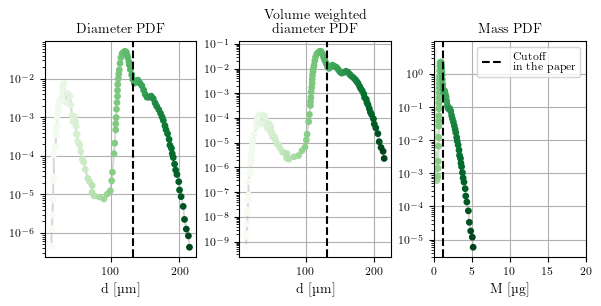

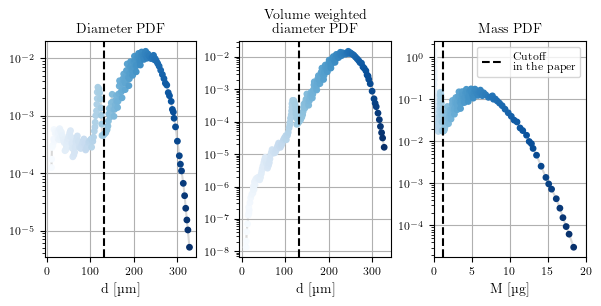

In [6]:
# plotDiameterComparisonsColors()
# test111 = MyProbs.initFromFolder("/home/erdi/Uni/LCGAStage/CleanLagrangianLaminarJet/Code/OutF2925X111_8", "111mm test")
# configureLatexPlot("beamer")
configureLatexPlot("article", aspect_ratio=4/2)
# configureLatexPlot("twocolumn", aspect_ratio=4/2)
plotDiameterComparisonsColors(exp_init11mm, log=True, cmap="Greens", grid=True, str_dia="11mm_" )#,figsize=(15, 4))
plotDiameterComparisonsColors(exp_end111mm, log=True, cmap="Blues" , grid=True, str_dia="111mm_")#,figsize=(15, 4))
# fig_axs = plotDiameterComparisonsColors(exp_init11mm, log=True, cmap="Greens", figsize=(15, 4), grid=True)
# plotDiameterComparisonsColors(exp_end111mm, log=True, cmap="Blues" , figsize=(15, 4), grid=True, fig_axs=fig_axs)

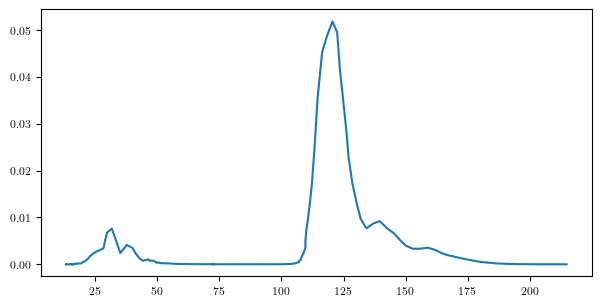

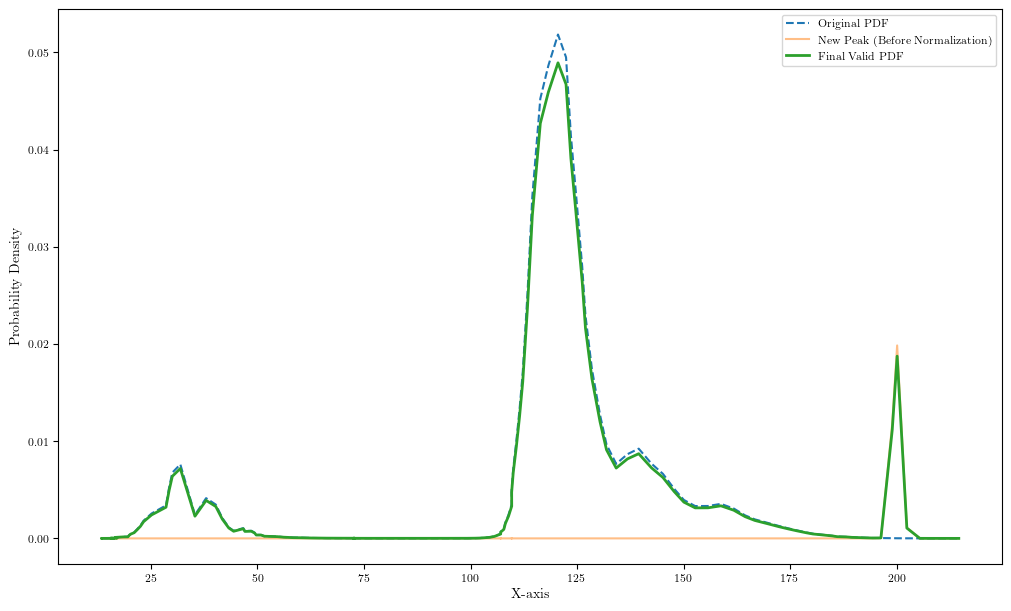

In [7]:
plt.figure()
# plt.plot( exp_init11mm.d_prob_weighted_dist_bin_centers, exp_init11mm.d_prob_density*1.049129e-4 - 1e-16*exp_init11mm.d_vol_weighted_ptob_dist/volumeSphere(exp_init11mm.d_prob_weighted_dist_bin_centers/2))
plt.plot(exp_init11mm.d_prob_dist_bin_centers*1e6, exp_init11mm.d_prob_density*1e-6)

import numpy as np
import matplotlib.pyplot as plt

# 1. Assign your existing data to variables for cleaner code
x = exp_init11mm.d_prob_dist_bin_centers * 1e6
y_original = exp_init11mm.d_prob_density * 1e-6

# 2. Define the parameters for your new peak
mu = 200          # Center of the peak
sigma = 1        # Standard deviation (width)
amplitude = 0.02  # Desired peak height

# 3. Generate the Gaussian peak over your existing x-axis
y_new_peak = amplitude * np.exp(-0.5 * ((x - mu) / sigma)**2)

# 4. Add the new peak to your original PDF
y_combined = y_original + y_new_peak

# 5. Preserve the PDF: Normalize so the total area remains exactly 1
# np.trapz calculates the integral (area under the curve)
total_area = np.trapezoid(y_combined, x)
y_final_pdf = y_combined / total_area

# 6. Plot the results to verify
plt.figure(figsize=(10, 6))
plt.plot(x, y_original, label='Original PDF', linestyle='--')
plt.plot(x, y_new_peak, label='New Peak (Before Normalization)', alpha=0.5)
plt.plot(x, y_final_pdf, label='Final Valid PDF', linewidth=2)

plt.xlabel('X-axis')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

Peak X-coordinates: [120.52832886 139.46911218 158.7645876 ]
Spacing between peaks (Delta x): [18.94078333 19.29547542]
Average spacing: 19.12

--- Reduction Law Parameters ---
Amplitude (A): 0.05177
Decay rate (b): 0.08748
Equation: y = 0.05177 * e^(-0.08748 * (x - 120.53))


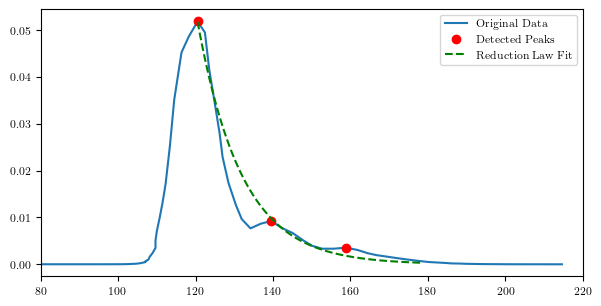

In [8]:
# THIS CELL WAS GENERATED USING GEMINI 

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# 1. Define your x and y data
x = exp_init11mm.d_prob_dist_bin_centers * 1e6
y = exp_init11mm.d_prob_density * 1e-6

# 2. Isolate data after the 100 x-axis mark
mask = x > 100
x_target = x[mask]
y_target = y[mask]

# 3. Detect the peaks
# prominence ensures we don't pick up tiny noise fluctuations as peaks
# peaks_indices, properties = find_peaks(y_target, prominence=0.001) 
# Lower the prominence to catch smaller trailing peaks
peaks_indices, properties = find_peaks(y_target, prominence=0.0001)

peak_x = x_target[peaks_indices]
peak_y = y_target[peaks_indices]

# 4. Analyze X-Axis Law (Spacing)
print("Peak X-coordinates:", peak_x)
if len(peak_x) > 1:
    spacing = np.diff(peak_x)
    print("Spacing between peaks (Delta x):", spacing)
    print(f"Average spacing: {np.mean(spacing):.2f}")

# # 5. Analyze the Reduction Law (Exponential Decay)
# def exp_decay(x, A, b, C):
#     return A * np.exp(-b * (x - peak_x[0])) + C

# # Fit the exponential curve to the peaks
# # p0 provides initial guesses for [A, b, C] to help the optimizer
# popt, pcov = curve_fit(exp_decay, peak_x, peak_y, p0=[peak_y[0], 0.1, 0])
# A, b, C = popt

# print("\n--- Reduction Law Parameters ---")
# print(f"Amplitude (A): {A:.5f}")
# print(f"Decay rate (b): {b:.5f}")
# print(f"Offset (C): {C:.5f}")
# print(f"Equation: y = {A:.5f} * e^(-{b:.5f} * (x - {peak_x[0]:.2f})) + {C:.5f}")

# 5. Analyze the Reduction Law (Exponential Decay with C=0)
def exp_decay_no_offset(x, A, b):
    return A * np.exp(-b * (x - peak_x[0]))

# Fit the 2-parameter exponential curve to the 2 peaks
popt, pcov = curve_fit(exp_decay_no_offset, peak_x, peak_y, p0=[peak_y[0], 0.1])
A, b = popt

print("\n--- Reduction Law Parameters ---")
print(f"Amplitude (A): {A:.5f}")
print(f"Decay rate (b): {b:.5f}")
print(f"Equation: y = {A:.5f} * e^(-{b:.5f} * (x - {peak_x[0]:.2f}))")

# 6. Plot to verify the results
plt.plot(x, y, label='Original Data')
plt.plot(peak_x, peak_y, 'ro', label='Detected Peaks')

# Generate points for the fitted smooth decay curve
x_fit = np.linspace(min(peak_x), max(peak_x) + 20, 100)
y_fit = exp_decay_no_offset(x_fit, *popt)
plt.plot(x_fit, y_fit, 'g--', label='Reduction Law Fit')

plt.xlim(80, 220) # Focus on the area of interest
plt.legend()
plt.show()

Plot configured for halfbeamer: 2.7559056316590564"x1.9405718555417186" at 11pt.


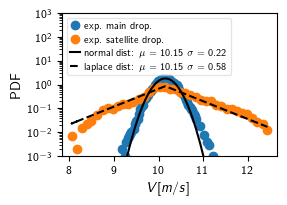

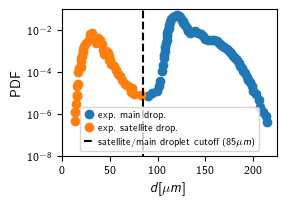

Plot configured for halfbeamer: 2.7559056316590564"x2.587429140722292" at 11pt.


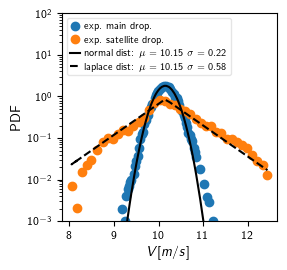

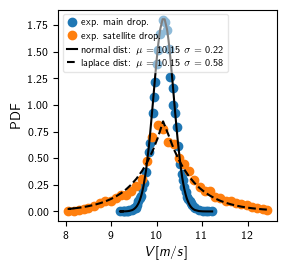

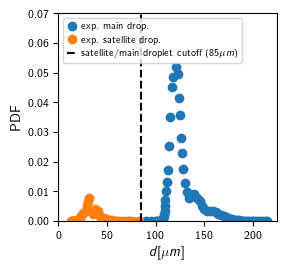

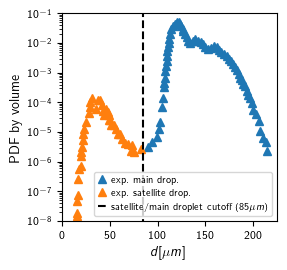

In [9]:
configureLatexPlot("halfbeamer", caption_spacer=0.6)#, aspect_ratio=1/0.9)
# configureLatexPlot("twocolumn")
plt.figure()
color_main ="tab:blue" #"#003968"
color_sat  ="tab:orange" #"#e8502e"
plt.plot(exp_init11mm.v_main_prob_dist_bin_centers    , exp_init11mm.v_main_prob_density    , "o", color=color_main, label = "exp. main drop.")
plt.plot(exp_init11mm.v_satelite_prob_dist_bin_centers, exp_init11mm.v_satelite_prob_density, "o", color=color_sat , label = "exp. satellite drop.")
plt.plot(exp_init11mm.v_main_prob_dist_bin_centers    , sps.norm   .pdf(exp_init11mm.v_main_prob_dist_bin_centers, 10.15, 0.22)    ,"-k", label = r"normal dist: $\mu=10.15$ $\sigma = 0.22$"  )#, color = color_main)
plt.plot(exp_init11mm.v_satelite_prob_dist_bin_centers, sps.laplace.pdf(exp_init11mm.v_satelite_prob_dist_bin_centers, 10.15, 0.58),"--k", label = r"laplace dist: $\mu=10.15$ $\sigma = 0.58$")#, color = color_sat)
plt.xlabel("$V [m/s]$")
plt.ylabel("PDF")
plt.yscale('log')
plt.legend(loc="upper left")
plt.ylim([1e-3,1000])
plt.legend(
    loc="upper left",
    fontsize=7, 
    handlelength=1.0, 
    handletextpad=0.4, 
    borderpad=0.4,
    framealpha=0.5
    
)
plt.savefig(figure_dir+"exp11mm_vel_pdf_log_lin.pdf", bbox_inches="tight")
plt.show()


plt.figure()
idx_main = exp_init11mm.d_prob_dist_bin_centers*1e6 > 85 
idx_sat  = exp_init11mm.d_prob_dist_bin_centers*1e6 < 85 
plt.plot(exp_init11mm.d_prob_dist_bin_centers[idx_main]*1e6, exp_init11mm.d_prob_density[idx_main]*1e-6, "o", color=color_main, label = "exp. main drop.")
plt.plot(exp_init11mm.d_prob_dist_bin_centers[idx_sat] *1e6, exp_init11mm.d_prob_density[idx_sat] *1e-6, "o", color=color_sat , label = "exp. satellite drop.")
plt.vlines(85, ymin=0, ymax = 0.1, linestyles="--", color = "k", label = r"satellite/main droplet cutoff ($85 \mu m$)")
plt.xlabel(r"$d [\mu m]$")
plt.ylabel("PDF")
plt.yscale('log')
plt.ylim([1e-8, 0.1])
plt.xlim([0, 225])
plt.legend(
    # loc="upper left",
    fontsize=7, 
    handlelength=1.0, 
    handletextpad=0.4, 
    borderpad=0.4,
)
plt.savefig(figure_dir+"exp11mm_dia_pdf_log_lin.pdf", bbox_inches="tight")
plt.show()

configureLatexPlot("halfbeamer", caption_spacer=0.8)#, aspect_ratio=1/0.9)

plt.figure()
color_main ="tab:blue" #"#003968"
color_sat  ="tab:orange" #"#e8502e"
plt.plot(exp_init11mm.v_main_prob_dist_bin_centers    , exp_init11mm.v_main_prob_density    , "o", color=color_main, label = "exp. main drop.")
plt.plot(exp_init11mm.v_satelite_prob_dist_bin_centers, exp_init11mm.v_satelite_prob_density, "o", color=color_sat , label = "exp. satellite drop.")
plt.plot(exp_init11mm.v_main_prob_dist_bin_centers    , sps.norm   .pdf(exp_init11mm.v_main_prob_dist_bin_centers, 10.15, 0.22)    ,"-k", label = r"normal dist: $\mu=10.15$ $\sigma = 0.22$"  )#, color = color_main)
plt.plot(exp_init11mm.v_satelite_prob_dist_bin_centers, sps.laplace.pdf(exp_init11mm.v_satelite_prob_dist_bin_centers, 10.15, 0.58),"--k", label = r"laplace dist: $\mu=10.15$ $\sigma = 0.58$")#, color = color_sat)
plt.xlabel("$V [m/s]$")
plt.ylabel("PDF")
plt.yscale('log')
plt.legend(loc="upper left")
plt.ylim([1e-3,100])
plt.legend(
    loc="upper left",
    fontsize=7, 
    handlelength=1.0, 
    handletextpad=0.4, 
    borderpad=0.4,
    framealpha=0.5
    
)
plt.savefig(figure_dir+"exp11mm_vel_pdf_log_lin_less_caption_space.pdf", bbox_inches="tight")
plt.show()


plt.figure()
color_main ="tab:blue" #"#003968"
color_sat  ="tab:orange" #"#e8502e"
plt.plot(exp_init11mm.v_main_prob_dist_bin_centers    , exp_init11mm.v_main_prob_density    , "o", color=color_main, label = "exp. main drop.")
plt.plot(exp_init11mm.v_satelite_prob_dist_bin_centers, exp_init11mm.v_satelite_prob_density, "o", color=color_sat , label = "exp. satellite drop.")
plt.plot(exp_init11mm.v_main_prob_dist_bin_centers    , sps.norm   .pdf(exp_init11mm.v_main_prob_dist_bin_centers, 10.15, 0.22)    ,"-k", label = r"normal dist: $\mu=10.15$ $\sigma = 0.22$"  )#, color = color_main)
plt.plot(exp_init11mm.v_satelite_prob_dist_bin_centers, sps.laplace.pdf(exp_init11mm.v_satelite_prob_dist_bin_centers, 10.15, 0.58),"--k", label = r"laplace dist: $\mu=10.15$ $\sigma = 0.58$")#, color = color_sat)
plt.xlabel("$V [m/s]$")
plt.ylabel("PDF")
# plt.yscale('log')
plt.legend(loc="upper left")
# plt.ylim([1e-3,100])
plt.legend(
    loc="upper left",
    fontsize=7, 
    handlelength=1.0, 
    handletextpad=0.4, 
    borderpad=0.4,
    framealpha=0.5
    
)
plt.savefig(figure_dir+"exp11mm_vel_pdf_lin_lin.pdf", bbox_inches="tight")
plt.show()

plt.figure()
idx_main = exp_init11mm.d_prob_dist_bin_centers*1e6 > 85 
idx_sat  = exp_init11mm.d_prob_dist_bin_centers*1e6 < 85 
plt.plot(exp_init11mm.d_prob_dist_bin_centers[idx_main]*1e6, exp_init11mm.d_prob_density[idx_main]*1e-6, "o", color=color_main, label = "exp. main drop.")
plt.plot(exp_init11mm.d_prob_dist_bin_centers[idx_sat] *1e6, exp_init11mm.d_prob_density[idx_sat] *1e-6, "o", color=color_sat , label = "exp. satellite drop.")
plt.vlines(85, ymin=0, ymax = 0.1, linestyles="--", color = "k", label = r"satellite/main droplet cutoff ($85 \mu m$)")
plt.xlabel(r"$d [\mu m]$")
plt.ylabel("PDF")
plt.ylim([0, 0.07])
plt.xlim([0, 225])
# plt.legend(loc="upper left")
plt.legend(
    loc="upper left",
    fontsize=7, 
    handlelength=1.0, 
    handletextpad=0.4, 
    borderpad=0.4
)
plt.savefig(figure_dir+"exp11mm_dia_pdf_lin_lin.pdf", bbox_inches="tight")
plt.show()


plt.figure()
plt.plot(exp_init11mm.d_prob_weighted_dist_bin_centers[idx_main]*1e6, exp_init11mm.d_vol_weighted_ptob_dist[idx_main]*1e-6, "^", color=color_main, label = "exp. main drop.")
plt.plot(exp_init11mm.d_prob_weighted_dist_bin_centers[idx_sat] *1e6, exp_init11mm.d_vol_weighted_ptob_dist[idx_sat] *1e-6, "^", color=color_sat , label = "exp. satellite drop.")
plt.vlines(85, ymin=0, ymax = 0.1, linestyles="--", color = "k", label = r"satellite/main droplet cutoff ($85 \mu m$)")
plt.xlabel(r"$d [\mu m]$")
plt.ylabel("PDF by volume")
plt.yscale('log')
plt.ylim([1e-8, 0.1])
plt.xlim([0, 225])
# plt.legend()#loc="upper left")
plt.legend(
    # loc="upper left",
    fontsize=7, 
    handlelength=1.0, 
    handletextpad=0.4, 
    borderpad=0.4
)
plt.savefig(figure_dir+"exp11mm_diapdf_vol_weight_pdf_log_lin.pdf", bbox_inches="tight")
plt.show()



In [10]:
from collections import defaultdict
import traceback
normal_simus_dir = "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/Normal/"
accelerated_simus_dir = "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/Acceleration/"
changing_distribution_dir = "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/NurmalDistDropTime/"
custom_dist_simus_dir = "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/At111mmNormalDist/"
changing_injection_rate_dir = "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/NormalDifferentTs/"
changing_colision_distance = "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/ColisionDistance/"
d_normal_frecs_dt2 = defaultdict(lambda: defaultdict(list))
every_normal_folders_dt2 = glob(normal_simus_dir+"*mm_dt1e-2*")#, recursive=True)
# print(every_normal_folders_dt2)

for f in every_normal_folders_dt2:
    splitted  = f.split("_")
    drop_freq = splitted[0].split("/")[-1]
    obj_dist  = splitted[1].split("mm")[0]
    dt        = splitted[2].split("dt")[-1]

    d_normal_frecs_dt2[drop_freq][obj_dist].append(f)
# print(d_normal_frecs_dt2.keys())
# print(d_normal_frecs_dt2.values())

def getEveryFreqGivenDtForProbDist(simu_dir, dt="1e-2"):
    d_frecs_dt = defaultdict(lambda: defaultdict(lambda:defaultdict(list)))
    folders_dt = glob(simu_dir+"*mm_dt"+dt+"*")#, recursive=True)

    for f in folders_dt:
        splitted  = f.split("_")
        print(splitted)
        drop_freq = splitted[0].split("/")[-1]
        dev       = splitted[1].split("dev")[-1]
        obj_dist  = splitted[2].split("mm")[0]
        dt        = splitted[3].split("dt")[-1]
        
        d_frecs_dt[drop_freq][dev][obj_dist].append(f)
    return d_frecs_dt

def getEveryFreqGivenDt(simu_dir, dt="1e-2"):
    d_frecs_dt = defaultdict(lambda: defaultdict(list))
    folders_dt = glob(simu_dir+"*mm_dt"+dt+"*")#, recursive=True)

    for f in folders_dt:
        splitted  = f.split("_")
        drop_freq = splitted[0].split("/")[-1]
        obj_dist  = splitted[1].split("mm")[0]
        dt        = splitted[2].split("dt")[-1]

        d_frecs_dt[drop_freq][obj_dist].append(f)
    return d_frecs_dt
assert(d_normal_frecs_dt2==getEveryFreqGivenDt(normal_simus_dir, dt="1e-2"))

l_every_normal_dt_dict            = [getEveryFreqGivenDt(normal_simus_dir                     , f"1e-{d}") for d in range(6)]
l_every_acceleration_dt_dict      = [getEveryFreqGivenDt(accelerated_simus_dir                , f"1e-{d}") for d in range(6)]
l_every_injection_rate_dt_dict    = [getEveryFreqGivenDt(changing_injection_rate_dir          , f"1e-{d}") for d in range(6)]
l_every_colision_distance_dt_dict = [getEveryFreqGivenDtForProbDist(changing_colision_distance, f"1e-{d}") for d in range(6)]
# l_every_custom_dt_dict = [getEveryFreqGivenDtForProbDist(custom_dist_simus_dir, f"1e-{d}") for d in range(6)]
d_every_custom_dist = getEveryFreqGivenDtForProbDist(custom_dist_simus_dir)
# print(l_every_normal_dt_dict[2]["29.25"])
# print(d_every_custom_dist)
# for k,v in d_every_custom_dist.items():
#     print(k, v)
#     print("\n")
def transformListToMyprobs(l_every_one, custom_distrib = False, n_bins = 500):
    l_every_one_myprobs = []
    for idx_dt, d_dt in enumerate(l_every_one):
        if d_dt is None: 
            l_every_one_myprobs.append(None)
            continue
        if custom_distrib:
            l_every_one_myprobs.append(defaultdict(lambda : defaultdict(lambda : defaultdict(lambda : None))))
            for injection_time, d_devs in d_dt.items():
                for prob_dev, d_lengths in d_devs.items():  
                    for length, l_folders in d_lengths.items():
                        # print(l_folders)
                        try:
                            l_every_one_myprobs[idx_dt][injection_time][prob_dev][length] = MyProbs.initFromFolderList(l_folders, label = length, n_bins=n_bins)
                        except Exception as e:
                            print(f"Error at {l_folders}")
                            print(f"The error message is: {repr(e)}")
                            traceback.print_exc()
        else:
            l_every_one_myprobs.append(defaultdict(lambda : defaultdict(lambda : None)))
            for injection_time, d_lengths in d_dt.items():
                for length, l_folders in d_lengths.items():
                    # print(l_folders)
                    try:
                        l_every_one_myprobs[idx_dt][injection_time][length] = MyProbs.initFromFolderList(l_folders, label = length, n_bins=n_bins)
                    except Exception as e:
                        print(f"Error at {l_folders}")
                        print(f"The error message is: {repr(e)}")
                        traceback.print_exc()
    return l_every_one_myprobs                


['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/ColisionDistance/29.25', 'dev1.25', '111mm', 'dt1e-2']
['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/ColisionDistance/29.25', 'dev1.25', '122mm', 'dt1e-2']
['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/ColisionDistance/29.25', 'dev1.25', '99mm', 'dt1e-2']
['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/ColisionDistance/29.25', 'dev1.5', '111mm', 'dt1e-2']
['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/ColisionDistance/29.25', 'dev1.5', '122mm', 'dt1e-2']
['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/ColisionDistance/29.25', 'dev1.5', '99mm', 'dt1e-2']
['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/ColisionDistance/29.25', 'dev2.5', '111mm', 'dt1e-2']
['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/ColisionDistance/29.25', 'dev2.5', '122mm', 'dt1e-2']
['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/ColisionDistance/29.25', 'd

In [11]:
l_myprobs_colision_distance_dict = transformListToMyprobs(l_every_colision_distance_dt_dict, custom_distrib=True)

111
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.999999
area under m distribution       = 0.9957094999999999
area under d prob*volume        = 0.9999967600195052
122
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999985
area under m distribution       = 0.9960079999999999
area under d prob*volume        = 0.9999941734220987
99
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999975
area under m distribution       = 0.99571
area under d prob*volume        = 0.9999971209674768
111
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999950000000002
area under m distribution       = 0.9957765
area under d prob*volume        = 0.9999968945993353
122
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999985
area under m distribution       = 0.9960045
area under d prob*volume        = 0.9999969973737306
99
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999985
area under m distribution      

In [12]:
l_myprobs_every_normal_dict = transformListToMyprobs(l_every_normal_dt_dict)


111
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999985000000001
area under m distribution       = 0.99582
area under d prob*volume        = 0.999996909591924
122
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999975000000001
area under m distribution       = 0.9959744999999999
area under d prob*volume        = 0.9999968264798156
22
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.999999
area under m distribution       = 0.9909395
area under d prob*volume        = 0.9999964369329009
33
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999975000000001
area under m distribution       = 0.9929345
area under d prob*volume        = 0.9999967583170004
44
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999979999999999
area under m distribution       = 0.993836
area under d prob*volume        = 0.9999936520515795
55
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999989999999999
area und

Plot configured for beamer: 5.511811263318113"x2.264000498132005" at 11pt.


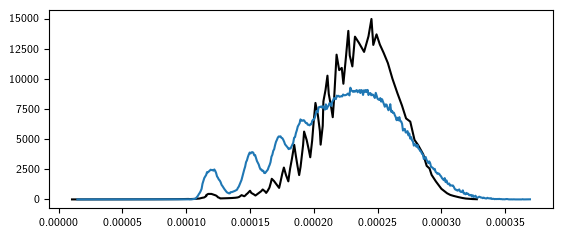

In [13]:
configureLatexPlot("beamer", )
plt.figure()
plotting_rn = l_myprobs_every_normal_dict[2]["29.25"]["111"]
plt.plot(exp_end111mm.d_prob_weighted_dist_bin_centers, exp_end111mm.d_vol_weighted_ptob_dist, color = "k", label="exp. 111mm")
plt.plot(plotting_rn.d_prob_weighted_dist_bin_centers, plotting_rn.d_vol_weighted_ptob_dist )
# plt.plot(plotting_rn.d_prob_dist_bin_centers, 3e11*plotting_rn.d_prob_density*volumeSphere(plotting_rn.d_prob_dist_bin_centers/2) )

In [14]:
l_myprobs_every_acceleration_dict = transformListToMyprobs(l_every_acceleration_dt_dict)

111
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999995
area under m distribution       = 0.9999964999999998
area under d prob*volume        = 0.9999985920240408


/home/erdi/Programs/PythonVenvs/GeneralPy314/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


22
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999985
area under m distribution       = 0.9999914999999999
area under d prob*volume        = 0.9999968113936355
33
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999990000000001
area under m distribution       = 0.999999
area under d prob*volume        = 0.9999969918752022
55
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999989999999999
area under m distribution       = 0.9999950000000001
area under d prob*volume        = 0.9999972298852832
88
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.999999
area under m distribution       = 0.9999990000000001
area under d prob*volume        = 0.9999974642637239
111
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.999999
area under m distribution       = 0.9999954999999999
area under d prob*volume        = 0.9999975267855791
122
NEED THE DIAMETERS IN METERS
Error at ['/home/erdi/Uni/LCGAStage/Jets/Lagrangia

Traceback (most recent call last):
  File "/tmp/ipykernel_72685/654089462.py", line 87, in transformListToMyprobs
    l_every_one_myprobs[idx_dt][injection_time][length] = MyProbs.initFromFolderList(l_folders, label = length, n_bins=n_bins)
                                                          ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/DataVis/myprobs.py", line 134, in initFromFolderList
    return cls(diameters  = diameters, velocities = velocities, label=label)
  File "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/DataVis/myprobs.py", line 74, in __init__
    self.v_main_prob_density, self.v_main_prob_dist_bin_centers, _         = getProbDenisty(self.v[self.d>75e-6], n_bins)
                                                                                            ~~~~~~^^^^^^^^^^^^^^
IndexError: boolean index did not match indexed array along axis 1; size of axis is 510000 but size of corresponding bool

133
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999966666666666
area under m distribution       = 0.99999
area under d prob*volume        = 0.9999915028876141
22
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999990000000001
area under m distribution       = 0.9999959999999999
area under d prob*volume        = 0.9999970456720052
33
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999989999999999
area under m distribution       = 0.999999
area under d prob*volume        = 0.9999970365108375
44
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.999999
area under m distribution       = 0.9999975
area under d prob*volume        = 0.9999969547787675
55
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999989999999999
area under m distribution       = 0.9999885000000001
area under d prob*volume        = 0.9999972945765798
88
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999983870967741

In [15]:
print(d_every_custom_dist)

l_myprobs_every_custom_dist_dict = transformListToMyprobs([None, None, d_every_custom_dist], custom_distrib=True)


defaultdict(<function getEveryFreqGivenDtForProbDist.<locals>.<lambda> at 0x7f1b88ed05c0>, {'29.25': defaultdict(<function getEveryFreqGivenDtForProbDist.<locals>.<lambda>.<locals>.<lambda> at 0x7f1b88ed2140>, {'0.01': defaultdict(<class 'list'>, {'111': ['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/At111mmNormalDist/29.25_dev0.01_111mm_dt1e-2']}), '12': defaultdict(<class 'list'>, {'111': ['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/At111mmNormalDist/29.25_dev12_111mm_dt1e-2']}), '1': defaultdict(<class 'list'>, {'111': ['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/At111mmNormalDist/29.25_dev1_111mm_dt1e-2']}), '3': defaultdict(<class 'list'>, {'111': ['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/At111mmNormalDist/29.25_dev3_111mm_dt1e-2']}), '6': defaultdict(<class 'list'>, {'111': ['/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Simus501/At111mmNormalDist/29.25_dev6_111mm_dt1e-2']}), '9': defaultdict(<class 'list'>, {'111': 

In [16]:
for l in l_myprobs_every_custom_dist_dict:
    print(l)
print(l_myprobs_every_custom_dist_dict[2]["29.25"])
for k, v in l_myprobs_every_custom_dist_dict[2]["29.25"].items():
    print(k)
    print(v["11"])

None
None
defaultdict(<function transformListToMyprobs.<locals>.<lambda> at 0x7f1b86245c70>, {'29.25': defaultdict(<function transformListToMyprobs.<locals>.<lambda>.<locals>.<lambda> at 0x7f1b88ed3740>, {'0.01': defaultdict(<function transformListToMyprobs.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda> at 0x7f1b862443b0>, {'111': <myprobs.MyProbs object at 0x7f1b8679fa50>}), '12': defaultdict(<function transformListToMyprobs.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda> at 0x7f1b86246610>, {'111': <myprobs.MyProbs object at 0x7f1b84c0d850>}), '1': defaultdict(<function transformListToMyprobs.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda> at 0x7f1b86244880>, {'111': <myprobs.MyProbs object at 0x7f1b84c0d950>}), '3': defaultdict(<function transformListToMyprobs.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda> at 0x7f1b86246090>, {'111': <myprobs.MyProbs object at 0x7f1b84c0db50>}), '6': defaultdict(<function transformListToMyprobs.<locals>.<lambda>.<locals>.<l

In [17]:
l_myprobs_every_injection_rate_dt_dict = transformListToMyprobs(l_every_injection_rate_dt_dict, n_bins=300)

111
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999985
area under m distribution       = 0.9949254999999999
area under d prob*volume        = 0.9999971771727811
122
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999980000000002
area under m distribution       = 0.995184
area under d prob*volume        = 0.999997184608596
99
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999990000000002
area under m distribution       = 0.9947300000000001
area under d prob*volume        = 0.9999972756031521
111
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999985
area under m distribution       = 0.9960884999999999
area under d prob*volume        = 0.9999972333194316
122
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999979999999999
area under m distribution       = 0.9962740000000001
area under d prob*volume        = 0.9999969879603742
99
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.99

In [18]:
configureLatexPlot("beamer", caption_spacer=0.75, column_size=0.9)

Plot configured for beamer: 4.9606301369863015"x2.4257148194271485" at 11pt.


In [19]:
import matplotlib.colors as mcolors
colors_b2g = ['#08306b', '#1f78b4', '#41ab5d']#, '#006d2c']
# colors_b2g = ["tab:blue", "tab:orange"]#, '#006d2c']
cmap_blue_green = mcolors.LinearSegmentedColormap.from_list("custom_b2g", colors_b2g)


In [20]:
def sortDict(D):
    return dict(sorted(D.items(), key=lambda item: float(item[0])))
    

In [21]:
for i, d in enumerate(l_myprobs_every_injection_rate_dt_dict):
    l_myprobs_every_injection_rate_dt_dict[i] = sortDict(d)

Plot configured for beamer: 5.511811263318113"x2.910857783312578" at 11pt.


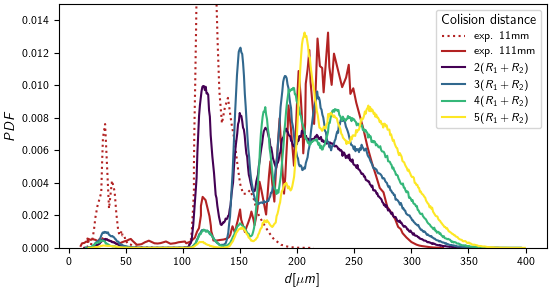

In [22]:
%matplotlib widget
configureLatexPlot("beamer", caption_spacer=0.9)
plt.figure()
plt.plot(exp_init11mm.d_prob_dist_bin_centers*1e6, exp_init11mm.d_prob_density*1e-6 , linestyle = ":"  , color = "firebrick", label = "exp. 11mm")
plt.plot(exp_end111mm.d_prob_dist_bin_centers*1e6, exp_end111mm.d_prob_density*1e-6 , linestyle = "-" , color = "firebrick", label = "exp. 111mm")
# # plt.plot(exp_init11mm.d_prob_dist_bin_centers*1e6, exp_init11mm.d_prob_density*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# # plt.plot(l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_dist_bin_centers*1e6, l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_density*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(exp_end111mm.d_prob_weighted_dist_bin_centers*1e6, exp_end111mm.d_vol_weighted_ptob_dist*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(exp_init11mm.d_prob_weighted_dist_bin_centers*1e6, exp_init11mm.d_vol_weighted_ptob_dist*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_weighted_dist_bin_centers*1e6, l_myprobs_every_normal_dict[2]["29.25"]["11"].d_vol_weighted_ptob_dist*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_dist_bin_centers*1e6, l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_density*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
sortDict(l_myprobs_colision_distance_dict[2]["29.25"])
colors = [plt.cm.viridis(i/3) for i in range(4)]
a=0
for i, (k, v) in enumerate(l_myprobs_colision_distance_dict[2]["29.25"].items()):
    if k not in {"2", "3", "4", "5"}: continue
    # if i > 6: break
    cur_dict_111mm = v["111"]
    plt.plot(cur_dict_111mm.d_prob_dist_bin_centers*1e6, cur_dict_111mm.d_prob_density*1e-6, label = k+r"$(R_1+R_2)$", color = colors[a])# plt.cm.viridis(float(k)/5))
    a+=1
plt.xlabel(r"$d [\mu m]$")
plt.ylabel(r"$PDF$")
# plt.xlim([0, 300])
plt.ylim([0, 0.015])
plt.legend(title = "Colision distance")
plt.savefig(figure_dir+"latest_change_colision_distance.pdf")

Plot configured for beamer: 5.511811263318113"x2.910857783312578" at 11pt.
defaultdict(<function transformListToMyprobs.<locals>.<lambda>.<locals>.<lambda> at 0x7f1b84a12da0>, {'111': <myprobs.MyProbs object at 0x7f1b84aa0050>, '122': <myprobs.MyProbs object at 0x7f1b84aa0250>, '99': <myprobs.MyProbs object at 0x7f1b84aa0150>})


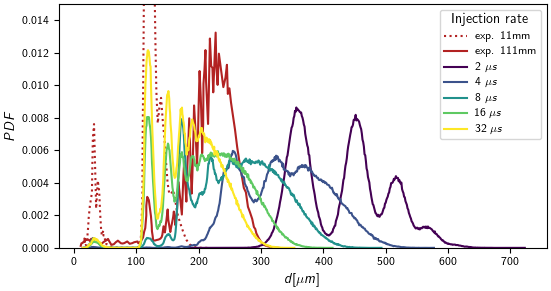

In [23]:
%matplotlib widget
configureLatexPlot("beamer", caption_spacer=0.9)
plt.figure()
print(l_myprobs_every_injection_rate_dt_dict[2]["2"])
plt.plot(exp_init11mm.d_prob_dist_bin_centers*1e6, exp_init11mm.d_prob_density*1e-6 , linestyle = ":" , color = "firebrick", label = "exp. 11mm")
plt.plot(exp_end111mm.d_prob_dist_bin_centers*1e6, exp_end111mm.d_prob_density*1e-6 , linestyle = "-" , color = "firebrick", label = "exp. 111mm")
# # plt.plot(exp_init11mm.d_prob_dist_bin_centers*1e6, exp_init11mm.d_prob_density*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# # plt.plot(l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_dist_bin_centers*1e6, l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_density*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(exp_end111mm.d_prob_weighted_dist_bin_centers*1e6, exp_end111mm.d_vol_weighted_ptob_dist*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(exp_init11mm.d_prob_weighted_dist_bin_centers*1e6, exp_init11mm.d_vol_weighted_ptob_dist*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_weighted_dist_bin_centers*1e6, l_myprobs_every_normal_dict[2]["29.25"]["11"].d_vol_weighted_ptob_dist*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_dist_bin_centers*1e6, l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_density*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
sortDict(l_myprobs_every_injection_rate_dt_dict[2])
colors = [plt.cm.viridis(i/4) for i in range(5)]
a=0
for i, (k, v) in enumerate(l_myprobs_every_injection_rate_dt_dict[2].items()):
    if k not in {"2", "4", "8", "16", "32"}: continue
    # if i > 6: break
    cur_dict_111mm = v["111"]
    plt.plot(cur_dict_111mm.d_prob_dist_bin_centers*1e6, cur_dict_111mm.d_prob_density*1e-6, label = k+r" $\mu s$", color = colors[a])#plt.cm.viridis(np.log2(int(k))/np.log2(32)))
    a+=1
plt.xlabel(r"$d [\mu m]$")
plt.ylabel(r"$PDF$")
# plt.xlim([0, 300])
plt.ylim([0, 0.015])
plt.legend(title = "Injection rate")
plt.savefig(figure_dir+"latest_injection_rate_change.pdf")

Plot configured for twocolumn: 3.5"x2.5" at 11pt.
defaultdict(<function transformListToMyprobs.<locals>.<lambda>.<locals>.<lambda> at 0x7f1b84a12da0>, {'111': <myprobs.MyProbs object at 0x7f1b84aa0050>, '122': <myprobs.MyProbs object at 0x7f1b84aa0250>, '99': <myprobs.MyProbs object at 0x7f1b84aa0150>})


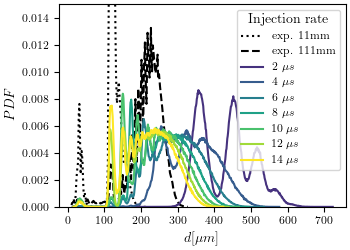

In [24]:
# %matplotlib widget
configureLatexPlot("twocolumn")
plt.figure()
print(l_myprobs_every_injection_rate_dt_dict[2]["2"])
plt.plot(exp_init11mm.d_prob_dist_bin_centers*1e6, exp_init11mm.d_prob_density*1e-6 , linestyle = ":", color = "k", label = "exp. 11mm")
plt.plot(exp_end111mm.d_prob_dist_bin_centers*1e6, exp_end111mm.d_prob_density*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# # plt.plot(exp_init11mm.d_prob_dist_bin_centers*1e6, exp_init11mm.d_prob_density*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# # plt.plot(l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_dist_bin_centers*1e6, l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_density*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(exp_end111mm.d_prob_weighted_dist_bin_centers*1e6, exp_end111mm.d_vol_weighted_ptob_dist*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(exp_init11mm.d_prob_weighted_dist_bin_centers*1e6, exp_init11mm.d_vol_weighted_ptob_dist*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_weighted_dist_bin_centers*1e6, l_myprobs_every_normal_dict[2]["29.25"]["11"].d_vol_weighted_ptob_dist*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")
# plt.plot(l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_dist_bin_centers*1e6, l_myprobs_every_normal_dict[2]["29.25"]["11"].d_prob_density*1e-6 , linestyle = "--" , color = "k", label = "exp. 111mm")


for i, (k, v) in enumerate(l_myprobs_every_injection_rate_dt_dict[2].items()):
    # if i%2 == 0: continue
    if i > 6: break
    cur_dict_111mm = v["111"]
    plt.plot(cur_dict_111mm.d_prob_dist_bin_centers*1e6, cur_dict_111mm.d_prob_density*1e-6, label = k+r" $\mu s$", color = plt.cm.viridis(int(k)/14))
plt.xlabel(r"$d [\mu m]$")
plt.ylabel(r"$PDF$")
# plt.xlim([0, 300])
plt.ylim([0, 0.015])
plt.legend(title = "Injection rate")

In [25]:
def sortLMyprobsDict(l_myprobs):
    for i,dt in enumerate(l_myprobs):
        for ij, d in l_myprobs[i].items():
            print(i, ij, d)
            l_myprobs[i][ij] = sortDict(l_myprobs[i][ij])
    return l_myprobs
# for i,dt in enumerate(l_myprobs_every_normal_dict):
#     for ij, d in l_myprobs_every_normal_dict[i].items():
#         print(i, ij, d)
#         l_myprobs_every_normal_dict[i][ij] = sortDict(l_myprobs_every_normal_dict[i][ij])
# assert(l_myprobs_every_normal_dict==sortLMyprobsDict(l_myprobs_every_normal_dict))
sortLMyprobsDict(l_myprobs_every_normal_dict)
# sortLMyprobsDict(l_myprobs_every_acceleration_dict)

2 29.00 defaultdict(<function transformListToMyprobs.<locals>.<lambda>.<locals>.<lambda> at 0x7f1b88ed3cc0>, {'111': <myprobs.MyProbs object at 0x7f1c1c20f150>, '122': <myprobs.MyProbs object at 0x7f1b89088750>, '22': <myprobs.MyProbs object at 0x7f1b89089d50>, '33': <myprobs.MyProbs object at 0x7f1b89089050>, '44': <myprobs.MyProbs object at 0x7f1b8908a050>, '55': <myprobs.MyProbs object at 0x7f1b89088c50>, '77': <myprobs.MyProbs object at 0x7f1b89088d50>, '99': <myprobs.MyProbs object at 0x7f1b89089e50>})
2 29.25 defaultdict(<function transformListToMyprobs.<locals>.<lambda>.<locals>.<lambda> at 0x7f1b88ed14e0>, {'111': <myprobs.MyProbs object at 0x7f1b89089350>, '11': <myprobs.MyProbs object at 0x7f1b89089c50>, '122': <myprobs.MyProbs object at 0x7f1b89089950>, '133': <myprobs.MyProbs object at 0x7f1b848edb50>, '155': <myprobs.MyProbs object at 0x7f1b848ee050>, '22000': <myprobs.MyProbs object at 0x7f1b848eef50>, '220': <myprobs.MyProbs object at 0x7f1b848ee250>, '22': <myprobs.MyPr

[defaultdict(<function __main__.transformListToMyprobs.<locals>.<lambda>()>,
             {}),
 defaultdict(<function __main__.transformListToMyprobs.<locals>.<lambda>()>,
             {}),
 defaultdict(<function __main__.transformListToMyprobs.<locals>.<lambda>()>,
             {'29.00': {'22': <myprobs.MyProbs at 0x7f1b89089d50>,
               '33': <myprobs.MyProbs at 0x7f1b89089050>,
               '44': <myprobs.MyProbs at 0x7f1b8908a050>,
               '55': <myprobs.MyProbs at 0x7f1b89088c50>,
               '77': <myprobs.MyProbs at 0x7f1b89088d50>,
               '99': <myprobs.MyProbs at 0x7f1b89089e50>,
               '111': <myprobs.MyProbs at 0x7f1c1c20f150>,
               '122': <myprobs.MyProbs at 0x7f1b89088750>},
              '29.25': {'11': <myprobs.MyProbs at 0x7f1b89089c50>,
               '22': <myprobs.MyProbs at 0x7f1b848ef750>,
               '33': <myprobs.MyProbs at 0x7f1b848ef450>,
               '44': <myprobs.MyProbs at 0x7f1b848ee850>,
               '

{'11': <myprobs.MyProbs object at 0x7f1b89089c50>, '22': <myprobs.MyProbs object at 0x7f1b848ef750>, '33': <myprobs.MyProbs object at 0x7f1b848ef450>, '44': <myprobs.MyProbs object at 0x7f1b848ee850>, '55': <myprobs.MyProbs object at 0x7f1b848ed950>, '85': <myprobs.MyProbs object at 0x7f1b848ef350>, '111': <myprobs.MyProbs object at 0x7f1b89089350>, '122': <myprobs.MyProbs object at 0x7f1b89089950>, '133': <myprobs.MyProbs object at 0x7f1b848edb50>, '155': <myprobs.MyProbs object at 0x7f1b848ee050>, '220': <myprobs.MyProbs object at 0x7f1b848ee250>, '333': <myprobs.MyProbs object at 0x7f1b848ef650>, '22000': <myprobs.MyProbs object at 0x7f1b848eef50>, '33000': <myprobs.MyProbs object at 0x7f1b848ee950>}
Plot configured for beamer: 5.511811263318113"x3.674540842212075" at 13pt.


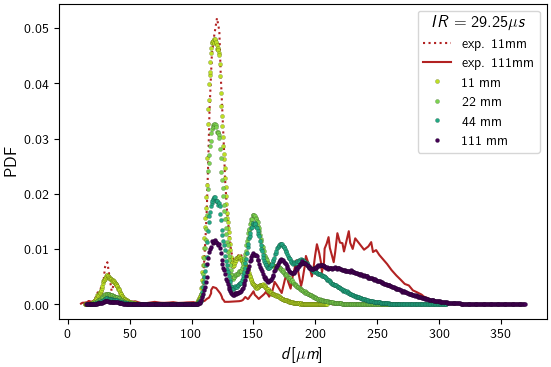

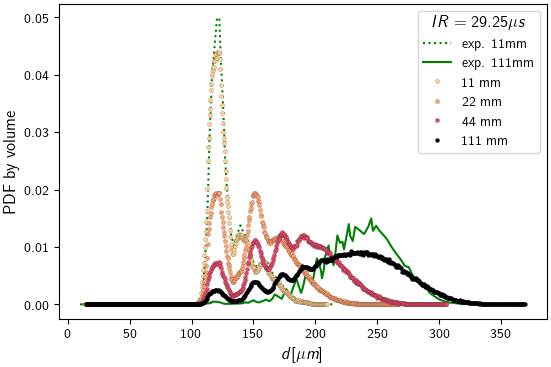

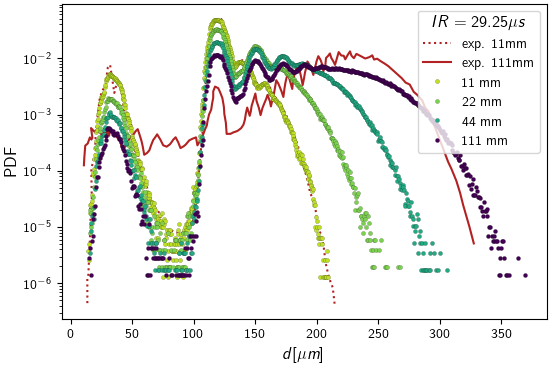

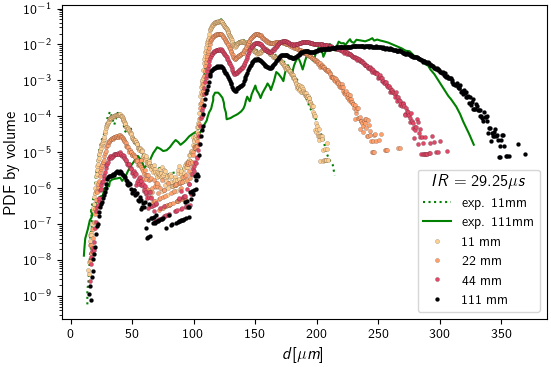

In [26]:
print(l_myprobs_every_normal_dict[2]["29.25"])
l_myprobs_every_normal_dict[2]["29.25"] = sortDict(l_myprobs_every_normal_dict[2]["29.25"])
# %matplotlib widget
configureLatexPlot("beamer", aspect_ratio=3/2, bigger_font_by=2)
# cmap_choosen = plt.cm.viridis_r
# cmap_choosen = plt.cm.cividis_r
# cmap_choosen = plt.cm.magma_r
def plotEvertLengthsUntil(distances_dict, legend_title="", until = 111, cmap_choosen = plt.cm.viridis_r, by_volume = False, save_fig_to = None, log=False):
    plt.figure()
    if by_volume:
        plt.plot(exp_init11mm.d_prob_weighted_dist_bin_centers*1e6, exp_init11mm.d_vol_weighted_ptob_dist*1e-6 , linestyle = ":" , color = "green", label = "exp. 11mm")
        plt.plot(exp_end111mm.d_prob_weighted_dist_bin_centers*1e6, exp_end111mm.d_vol_weighted_ptob_dist*1e-6 , linestyle = "-" , color = "green", label = "exp. 111mm")
    else:
        plt.plot(exp_init11mm.d_prob_dist_bin_centers*1e6, exp_init11mm.d_prob_density*1e-6 , linestyle = ":" , color = "firebrick", label = "exp. 11mm")
        plt.plot(exp_end111mm.d_prob_dist_bin_centers*1e6, exp_end111mm.d_prob_density*1e-6 , linestyle = "-" , color = "firebrick", label = "exp. 111mm")
    linesyle = "o"
    for k, v_prob in distances_dict.items():
        # print(k, int(k), v_prob)
        if type(until) is list:
            if int(k) in until:
                if by_volume:
                    plt.plot(v_prob.d_prob_weighted_dist_bin_centers*1e6, v_prob.d_vol_weighted_ptob_dist*1e-6, linesyle, markersize = 3, label = k+" mm",markeredgecolor="k", markeredgewidth=0.1, color = cmap_choosen(int(k)/max(until)) )
                else:
                    plt.plot(v_prob.d_prob_dist_bin_centers*1e6, v_prob.d_prob_density*1e-6                   , linesyle, markersize = 3, label = k+" mm",markeredgecolor="k", markeredgewidth=0.1, color = cmap_choosen(int(k)/max(until)) ) 
        elif int(k) <= until:
            if by_volume:
                plt.plot(v_prob.d_prob_weighted_dist_bin_centers*1e6, v_prob.d_vol_weighted_ptob_dist*1e-6, linesyle, markersize = 3, label = k+" mm",markeredgecolor="k", markeredgewidth=0.1, color = cmap_choosen(int(k)/until) )
            else:
                plt.plot(v_prob.d_prob_dist_bin_centers*1e6, v_prob.d_prob_density*1e-6                   , linesyle, markersize = 3, label = k+" mm",markeredgecolor="k", markeredgewidth=0.1, color = cmap_choosen(int(k)/until) )
    plt.xlabel(r"$d[\mu m]$")
    if by_volume:
        plt.ylabel(r"PDF by volume")
    else:
        plt.ylabel(r"PDF")
    if log: plt.yscale('log')
    plt.legend(title = legend_title)
    if save_fig_to is not None:
        plt.savefig(save_fig_to)

# plotEvertLengthsUntil(l_myprobs_every_normal_dict[2]["29.00"], r"$IR=29.00\mu s$", 111, plt.cm.magma_r)#, plt.cm.Greens)
plotEvertLengthsUntil(l_myprobs_every_normal_dict[2]["29.25"], r"$IR=29.25\mu s$", [11, 22, 44, 111], plt.cm.viridis_r              , save_fig_to=figure_dir+"scatter_plot_bigger_font_pdf_d_ij29.25_lin_lin.pdf")#, plt.cm.Greens)
plotEvertLengthsUntil(l_myprobs_every_normal_dict[2]["29.25"], r"$IR=29.25\mu s$", [11, 22, 44, 111], plt.cm.magma_r, by_volume=True, save_fig_to=figure_dir+"scatter_plot_bigger_font_vol_pdf_d_ij29.25_lin_lin.pdf")#, plt.cm.Greens)
plotEvertLengthsUntil(l_myprobs_every_normal_dict[2]["29.25"], r"$IR=29.25\mu s$", [11, 22, 44, 111], plt.cm.viridis_r              , save_fig_to=figure_dir+"scatter_plot_bigger_font_pdf_d_ij29.25_lin_log.pdf"    , log=True)#, plt.cm.Greens)
plotEvertLengthsUntil(l_myprobs_every_normal_dict[2]["29.25"], r"$IR=29.25\mu s$", [11, 22, 44, 111], plt.cm.magma_r, by_volume=True, save_fig_to=figure_dir+"scatter_plot_bigger_font_vol_pdf_d_ij29.25_lin_log.pdf", log=True)#, plt.cm.Greens)
# plotEvertLengthsUntil(l_myprobs_every_normal_dict[2]["29.75"], r"$IR=29.75\mu s$", 111, plt.cm.cividis_r)#, plt.cm.Greens)
# plotEvertLengthsUntil(l_myprobs_every_normal_dict[2]["29.75"], r"$IR=29.75\mu s$", 111, plt.cm.cividis_r)#, plt.cm.Greens)
# plotEvertLengthsUntil(l_myprobs_every_normal_dict[2]["29.25"], r"$IR=29.25\mu s$", 133, by_volume=True)#, plt.cm.Greens)

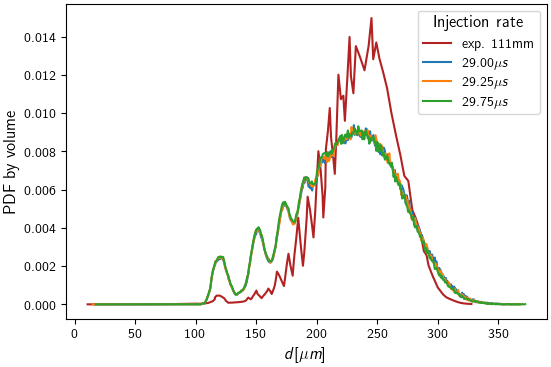

In [27]:
plt.figure()
plt.plot(exp_end111mm.d_prob_weighted_dist_bin_centers*1e6, exp_end111mm.d_vol_weighted_ptob_dist*1e-6 , linestyle = "-" , color = "firebrick", label = "exp. 111mm")
l_injection_rates = ["29.00","29.25","29.75"]
l_comparisons_IJ = [l_myprobs_every_normal_dict[2][ij]["111"] for ij in l_injection_rates]
for i, probs in enumerate(l_comparisons_IJ):
    plt.plot(probs.d_prob_weighted_dist_bin_centers*1e6, probs.d_vol_weighted_ptob_dist*1e-6 , linestyle = "-", label = "$"+l_injection_rates[i]+r"\mu s$")
plt.ylabel(r"PDF by volume")
plt.xlabel(r"$d[\mu m]$")
# plt.yscale('log')
plt.legend(title="Injection rate")
plt.savefig(figure_dir+"pdf_d_different_ij.pdf")

Plot configured for beamer: 4.9606301369863015"x2.4257148194271485" at 11pt.


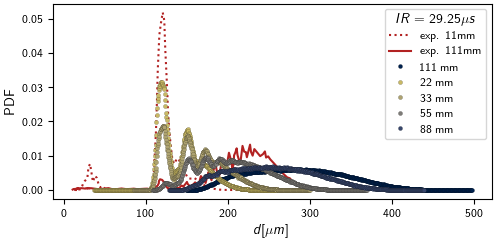

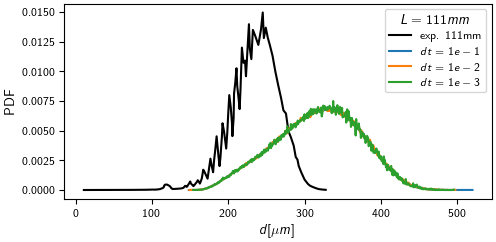

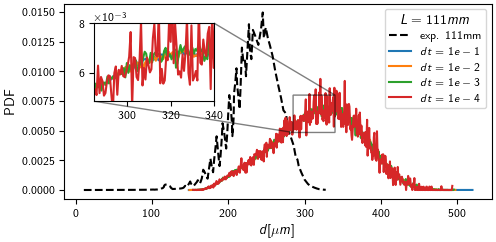

In [28]:
configureLatexPlot("beamer", caption_spacer=0.75, column_size=0.9)

plotEvertLengthsUntil(l_myprobs_every_acceleration_dict[2]["29.25"], r"$IR=29.25\mu s$", [22, 33, 55, 88, 111], plt.cm.cividis_r, save_fig_to=figure_dir+"pdf_d_with_acc1_lin_lin.pdf")#, plt.cm.Greens)
plt.figure()
plt.plot(exp_end111mm.d_prob_weighted_dist_bin_centers*1e6, exp_end111mm.d_vol_weighted_ptob_dist*1e-6 , linestyle = "-" , color = "k", label = "exp. 111mm")
for i in range(4):
    try: 
        probs = l_myprobs_every_acceleration_dict[i]["29.25"]["111"]
    except:
        continue
    if probs is None: continue
    plt.plot(probs.d_prob_weighted_dist_bin_centers*1e6, probs.d_vol_weighted_ptob_dist*1e-6 , linestyle = "-", label = f"$dt=1e-{i}$")
plt.ylabel(r"PDF")
plt.xlabel(r"$d[\mu m]$")
# plt.yscale('log')
plt.legend(title = "$L=111mm$")
# plt.savefig(figure_dir+"pdf_d_with_acc1_lin_lin.pdf")

plt.figure()
ax = plt.gca()

# 1. Create inset axes at top-left ([x0, y0, width, height] in relative axes coordinates)
axins = ax.inset_axes([0.07, 0.5, 0.28, 0.4]) 

# 2. Extract data to avoid repeating long names, and plot to BOTH ax and axins
x_exp = exp_end111mm.d_prob_weighted_dist_bin_centers*1e6
y_exp = exp_end111mm.d_vol_weighted_ptob_dist*1e-6
ax.plot(x_exp, y_exp, linestyle="--", color="k", label="exp. 111mm")
axins.plot(x_exp, y_exp, linestyle="-", color="k")
for i in range(5):
    try: 
        probs = l_myprobs_every_acceleration_dict[i]["29.25"]["111"]
    except:
        continue
    if probs is None: continue
    
    x_prob = probs.d_prob_weighted_dist_bin_centers*1e6
    y_prob = probs.d_vol_weighted_ptob_dist*1e-6
    ax.plot(x_prob, y_prob, linestyle="-", label=f"$dt=1e-{i}$")
    axins.plot(x_prob, y_prob, linestyle="-")

plt.ylabel(r"PDF")
plt.xlabel(r"$d[\mu m]$")
plt.legend(title="$L=111mm$")

# 3. Set the specific zoom limits you requested
axins.set_xlim(285, 340)
axins.set_ylim(0.00485, 0.0080)
axins.patch.set_alpha(0.7)
axins.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
# Optional but recommended: Adds the connecting lines from the zoom box to the main plot
ax.indicate_inset_zoom(axins, edgecolor="black")
plt.savefig(figure_dir+"pdf_d_different_dt_for_acc_lin_lin.pdf")

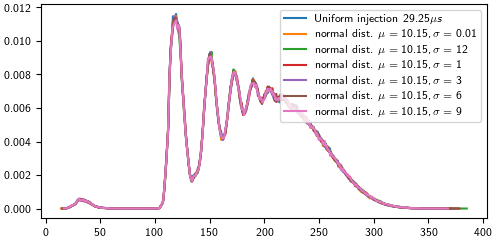

In [29]:
plt.figure()
# plt.plot(exp_end111mm.d_prob_dist_bin_centers*1e6, exp_end111mm.d_prob_density*1e-6 , linestyle = "-" , color = "k", label = "exp. 111mm")
plt.plot(l_myprobs_every_normal_dict[2]["29.25"]["111"].d_prob_dist_bin_centers*1e6, l_myprobs_every_normal_dict[2]["29.25"]["111"].d_prob_density*1e-6, label = r"Uniform injection $29.25\mu s$")
for dev, d_dev in l_myprobs_every_custom_dist_dict[2]["29.25"].items():
    plt.plot(d_dev["111"].d_prob_dist_bin_centers*1e6, d_dev["111"].d_prob_density*1e-6 , label = rf"normal dist. $\mu = 10.15, \sigma = {dev}$")
plt.legend()



Plot configured for beamer: 4.9606301369863015"x2.4257148194271485" at 11pt.


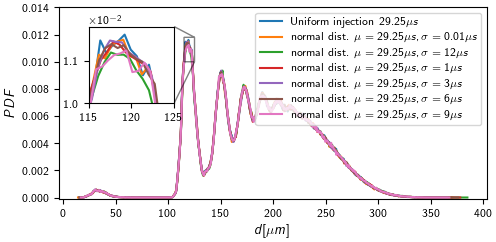

In [30]:
configureLatexPlot("beamer", caption_spacer=0.75, column_size=0.9)
plt.figure()
ax = plt.gca()

axins = ax.inset_axes([0.07, 0.5, 0.2, 0.4]) 
axins.patch.set_alpha(0.8) # Keeps the background slightly opaque so gridlines don't clash

x_exp = exp_end111mm.d_prob_dist_bin_centers * 1e6
y_exp = exp_end111mm.d_prob_density * 1e-6

# ax.plot(x_exp, y_exp, linestyle="-", color="k", label="exp. 111mm")
# axins.plot(x_exp, y_exp, linestyle="-", color="k")

uniform_prob = l_myprobs_every_normal_dict[2]["29.25"]["111"]
x_uni = uniform_prob.d_prob_dist_bin_centers * 1e6
y_uni = uniform_prob.d_prob_density * 1e-6

ax.plot(x_uni, y_uni, label=r"Uniform injection $29.25\mu s$")
axins.plot(x_uni, y_uni)

for dev, d_dev in l_myprobs_every_custom_dist_dict[2]["29.25"].items():
    custom_prob = d_dev["111"]
    x_cust = custom_prob.d_prob_dist_bin_centers * 1e6
    y_cust = custom_prob.d_prob_density * 1e-6
    
    label_str = rf"normal dist. $\mu = 29.25\mu s, \sigma = {dev}\mu s$"
    ax.plot(x_cust, y_cust, label=label_str)
    axins.plot(x_cust, y_cust)

axins.set_xlim(115, 125)
axins.set_ylim(0.0100, 0.0118)
axins.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.indicate_inset_zoom(axins, edgecolor="black")

plt.ylim([-1e-4, 0.014])
plt.legend()
plt.xlabel(r"$d[\mu m]$")
plt.ylabel("$PDF$")
plt.savefig(figure_dir+"pdf_d_ij_different_dists_lin_lin_zoomed.pdf")
plt.show()



NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9993266666666668
area under m distribution       = 0.99442
area under d prob*volume        = 0.9999464674458134


/home/erdi/Programs/PythonVenvs/GeneralPy314/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


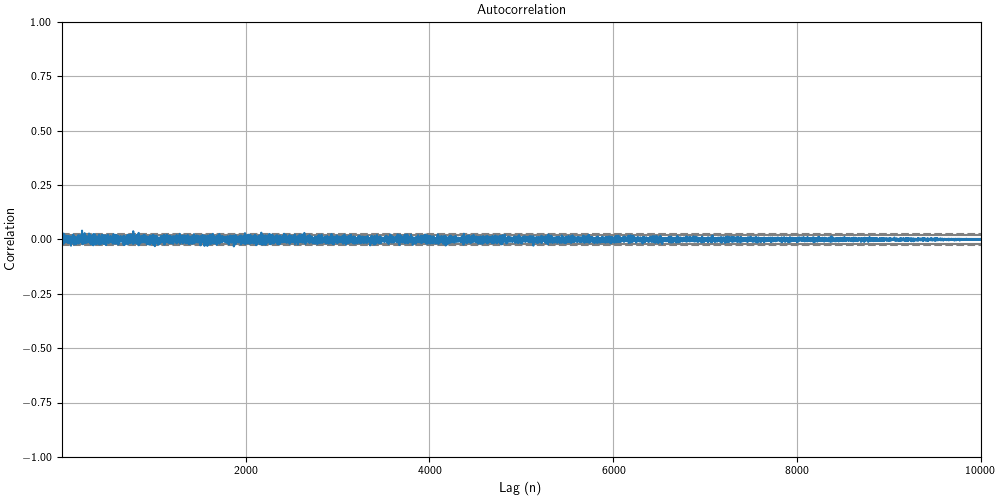

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

simu = MyProbs.initFromFolder("/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Out29_25_111mmUniformDia100_165um_and_Vel9_11", label="")# l_myprobs_every_normal_dict[2]["29.25"]["11"]
print(simu)
# print(len(simu.d[0]))
# print(len(simu.v[0]))Figure 4
# Figure 5
# Figure 6
# <matplotlib.legend.Legend at 0x7f99593aef90>
# Figure 7
# Figure 8

n=10000
# d_arr = np.array(simu.d[0][:n])*1e6
# idx = d_arr > 85
# v_arr = np.array(simu.v[0][:n])

d_arr = np.array(simu.d[:n])*1e6
idx = d_arr > 85
v_arr = np.array(simu.v[:n])
inter = np.ravel(np.column_stack((d_arr[idx], v_arr[idx])))
inter = np.array(simu.d[:n])*1e6
data_series = pd.Series(inter)

plt.figure(figsize=(10, 5))
pd.plotting.autocorrelation_plot(data_series)

plt.title("Autocorrelation")
plt.xlabel("Lag (n)")
plt.ylabel("Correlation")
plt.show()

Plot configured for beamer: 5.511811263318113"x2.587429140722292" at 11pt.


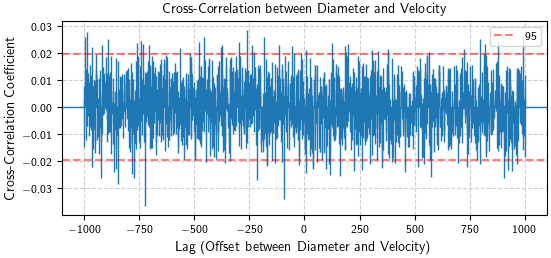

In [32]:
# import numpy as np
# import matplotlib.pyplot as plt
# configureLatexPlot("beamer")
configureLatexPlot("beamer", caption_spacer=0.8, column_size=1)

simu = l_myprobs_every_normal_dict[2]["29.25"]["11"]
d_array = np.array(simu.d[0][:10000]) * 1e6
v_array = np.array(simu.v[0][:10000])

d_centered = d_array - np.mean(d_array)
v_centered = v_array - np.mean(v_array)

plt.figure()

plt.xcorr(d_centered, v_centered, maxlags=1000, usevlines=True, normed=True, lw=1)

conf_level = 1.96 / np.sqrt(len(d_array))
plt.axhline(conf_level, color='red', linestyle='--', alpha=0.5, label='95% Confidence')
plt.axhline(-conf_level, color='red', linestyle='--', alpha=0.5)

plt.title("Cross-Correlation between Diameter and Velocity")
plt.xlabel("Lag (Offset between Diameter and Velocity)")
plt.ylabel("Cross-Correlation Coefficient")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(figure_dir+"cross_corelation_vel_dia_29.25_11mm.pdf")
plt.show()

Plot configured for halfbeamer: 2.7559056316590564"x2.587429140722292" at 11pt.
Optimized from your guess: m=2.484, t=11.297
Optimized from your guess: m=1.989, t=4.095
Gamma fit all data: shape=1.831, loc=-0.061, scale=2.311
Lognormal fit all data: shape=0.668, loc=-0.582, scale=3.851


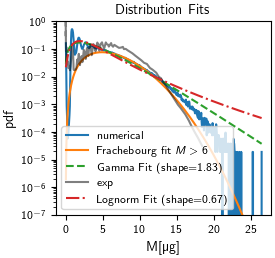

In [33]:
configureLatexPlot("halfbeamer", caption_spacer=0.8)
from scipy.optimize import curve_fit
from scipy.stats import gamma, lognorm
import numpy as np
import matplotlib.pyplot as plt
from frichebourg import *
redo111mm = l_myprobs_every_normal_dict[2]["29.25"]["111"]
# redo111mm = l_myprobs_every_acceleration_dict[2]["29.25"]["111"]
print(redo111mm)
bin_centers   = redo111mm.m_prob_dist_bin_centers*1e9
probabilities = redo111mm.m_prob_density*1e-9

plt.figure()
plt.plot(bin_centers, probabilities, label="numerical")
# plt.hist(raw_data, bins=b, weights=weights)#, edgecolor='black')

def frichebourgAnaRhoFit(M, m, t):
    Mp = M/(t**(2/3))
    return m*m/(pow(t,(4/3)))*frichebourgF(Mp)

nn = bin_centers > 6 #probabilities < 35e-3
# popt, pcov = curve_fit(frichebourgAnaRhoFit, bin_centers[nn], probabilities[nn])

guess = [0.7, 10.0]
# Add physical boundaries (m and t must be positive, and maybe t shouldn't exceed 50)
lower_bounds = [0.001, 0.001]
upper_bounds = [10.0, 50.0]

popt, pcov = curve_fit(
    frichebourgAnaRhoFit,
    bin_centers[nn],
    probabilities[nn],
    p0=guess,
    bounds=(lower_bounds, upper_bounds)
)

print(f"Optimized from your guess: m={popt[0]:.3f}, t={popt[1]:.3f}")
m_opt, t_opt = popt

# plt.plot(bin_centers[nn], probabilities[nn])
plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, m_opt, t_opt), label = "Frachebourg fit $M>6$")

guess = [0.7, 10.0]
lower_bounds = [0.001, 0.001]
upper_bounds = [10.0, 50.0]

popt, pcov = curve_fit(
    frichebourgAnaRhoFit,
    bin_centers,
    probabilities,
    p0=guess,
    bounds=(lower_bounds, upper_bounds)
)

print(f"Optimized from your guess: m={popt[0]:.3f}, t={popt[1]:.3f}")
m_opt, t_opt = popt
# plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, m_opt, t_opt), label = "frichebourg fit all data")
# plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, 1/2, 12), label="hand fit")

# --- Gamma Fit (All data) ---
bin_width = redo111mm.m_prob_dist_bin_centers[2] - redo111mm.m_prob_dist_bin_centers[1] 
r_data = redo111mm.m[0]*1e9  
shape, loc, scale = gamma.fit(r_data)
print(f"Gamma fit all data: shape={shape:.3f}, loc={loc:.3f}, scale={scale:.3f}")
gamma_pdf = gamma.pdf(bin_centers, shape, loc=loc, scale=scale)
plt.plot(bin_centers, gamma_pdf, label=f'Gamma Fit (shape={shape:.2f})', linestyle='--')
plt.plot(exp_end111mm.m_prob_dist_bin_centers*1e9, exp_end111mm.m_prob_density*1e-9, color = "k", alpha = 0.5, label = "exp")

# # --- Gamma Fit (m > 5) ---
# bin_width = redo111mm.m_prob_dist_bin_centers[2] - redo111mm.m_prob_dist_bin_centers[1] 
# r_data_filtered = np.array([m for m in redo111mm.m[0]*1e9 if m > 1])
# shape_f, loc_f, scale_f = gamma.fit(r_data_filtered)
# print(f"Gamma fit m>1: shape={shape_f:.3f}, loc={loc_f:.3f}, scale={scale_f:.3f}")
# gamma_pdf_f = gamma.pdf(bin_centers, shape_f, loc=0, scale=scale_f)
# plt.plot(bin_centers, gamma_pdf_f, label=f'Gamma Fit m>1 (shape={shape_f:.2f})', linestyle='--')

# --- Lognormal Fit (All data) ---
shape_log, loc_log, scale_log = lognorm.fit(r_data)
print(f"Lognormal fit all data: shape={shape_log:.3f}, loc={loc_log:.3f}, scale={scale_log:.3f}")
lognorm_pdf = lognorm.pdf(bin_centers, shape_log, loc=loc_log, scale=scale_log)
plt.plot(bin_centers, lognorm_pdf, label=f'Lognorm Fit (shape={shape_log:.2f})', linestyle='-.')

plt.ylabel('pdf')
plt.ylim([1e-7, 1])
# plt.xlim([0,  20])
plt.yscale('log')
plt.xlabel("M[µg]")
plt.title('Distribution Fits')
plt.legend()
plt.savefig(figure_dir+"probability_fit_normal.pdf")
plt.show()

Plot configured for halfbeamer: 2.7559056316590564"x2.587429140722292" at 11pt.
Optimized from your guess: m=2.484, t=11.297
Optimized from your guess: m=1.989, t=4.095


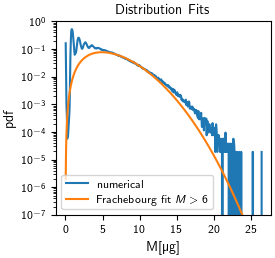

In [34]:
configureLatexPlot("halfbeamer", caption_spacer=0.8)
from scipy.optimize import curve_fit
from scipy.stats import gamma, lognorm
import numpy as np
import matplotlib.pyplot as plt
from frichebourg import *
redo111mm = l_myprobs_every_normal_dict[2]["29.25"]["111"]
# redo111mm = l_myprobs_every_acceleration_dict[2]["29.25"]["111"]
print(redo111mm)
bin_centers   = redo111mm.m_prob_dist_bin_centers*1e9
probabilities = redo111mm.m_prob_density*1e-9

plt.figure()
plt.plot(bin_centers, probabilities,label="numerical")#, markersize=3)
# plt.hist(raw_data, bins=b, weights=weights)#, edgecolor='black')

def frichebourgAnaRhoFit(M, m, t):
    Mp = M/(t**(2/3))
    return m*m/(pow(t,(4/3)))*frichebourgF(Mp)

nn = bin_centers > 6 #probabilities < 35e-3
# popt, pcov = curve_fit(frichebourgAnaRhoFit, bin_centers[nn], probabilities[nn])

guess = [0.7, 10.0]
# Add physical boundaries (m and t must be positive, and maybe t shouldn't exceed 50)
lower_bounds = [0.001, 0.001]
upper_bounds = [10.0, 50.0]

popt, pcov = curve_fit(
    frichebourgAnaRhoFit,
    bin_centers[nn],
    probabilities[nn],
    p0=guess,
    bounds=(lower_bounds, upper_bounds)
)

print(f"Optimized from your guess: m={popt[0]:.3f}, t={popt[1]:.3f}")
m_opt, t_opt = popt

# plt.plot(bin_centers[nn], probabilities[nn])
plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, m_opt, t_opt), label = "Frachebourg fit $M>6$")

guess = [0.7, 10.0]
lower_bounds = [0.001, 0.001]
upper_bounds = [10.0, 50.0]

popt, pcov = curve_fit(
    frichebourgAnaRhoFit,
    bin_centers,
    probabilities,
    p0=guess,
    bounds=(lower_bounds, upper_bounds)
)

print(f"Optimized from your guess: m={popt[0]:.3f}, t={popt[1]:.3f}")
m_opt, t_opt = popt
# plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, m_opt, t_opt), label = "frichebourg fit all data")
# plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, 1/2, 12), label="hand fit")

# # --- Gamma Fit (All data) ---
# bin_width = redo111mm.m_prob_dist_bin_centers[2] - redo111mm.m_prob_dist_bin_centers[1] 
# r_data = redo111mm.m[0]*1e9  
# shape, loc, scale = gamma.fit(r_data)
# print(f"Gamma fit all data: shape={shape:.3f}, loc={loc:.3f}, scale={scale:.3f}")
# gamma_pdf = gamma.pdf(bin_centers, shape, loc=loc, scale=scale)
# plt.plot(bin_centers, gamma_pdf, label=f'Gamma Fit (shape={shape:.2f})', linestyle='--')
# plt.plot(exp_end111mm.m_prob_dist_bin_centers*1e9, exp_end111mm.m_prob_density*1e-9, color = "k", alpha = 0.5, label = "exp")

# # --- Gamma Fit (m > 5) ---
# bin_width = redo111mm.m_prob_dist_bin_centers[2] - redo111mm.m_prob_dist_bin_centers[1] 
# r_data_filtered = np.array([m for m in redo111mm.m[0]*1e9 if m > 1])
# shape_f, loc_f, scale_f = gamma.fit(r_data_filtered)
# print(f"Gamma fit m>1: shape={shape_f:.3f}, loc={loc_f:.3f}, scale={scale_f:.3f}")
# gamma_pdf_f = gamma.pdf(bin_centers, shape_f, loc=0, scale=scale_f)
# plt.plot(bin_centers, gamma_pdf_f, label=f'Gamma Fit m>1 (shape={shape_f:.2f})', linestyle='--')

# # --- Lognormal Fit (All data) ---
# shape_log, loc_log, scale_log = lognorm.fit(r_data)
# print(f"Lognormal fit all data: shape={shape_log:.3f}, loc={loc_log:.3f}, scale={scale_log:.3f}")
# lognorm_pdf = lognorm.pdf(bin_centers, shape_log, loc=loc_log, scale=scale_log)
# plt.plot(bin_centers, lognorm_pdf, label=f'Lognorm Fit (shape={shape_log:.2f})', linestyle='-.')

plt.ylabel('pdf')
plt.ylim([1e-7, 1])
# plt.xlim([0,  20])
plt.yscale('log')
plt.xlabel("M[µg]")
plt.title('Distribution Fits')
plt.legend()
plt.savefig(figure_dir+"probability_fit_normal_frachebourg.pdf")
plt.show()

Plot configured for halfbeamer: 2.7559056316590564"x2.587429140722292" at 11pt.
Optimized from your guess (M>3): m=2.447, t=13.606
Optimized from your guess (All data): m=3.090, t=12.815


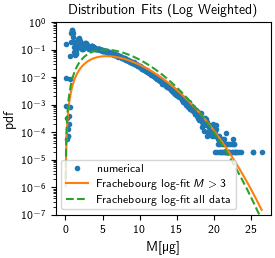

In [35]:
configureLatexPlot("halfbeamer", caption_spacer=0.8)
from scipy.optimize import curve_fit
from scipy.stats import gamma, lognorm
import numpy as np
import matplotlib.pyplot as plt
from frichebourg import *

# --- 1. Load Data ---
redo111mm = l_myprobs_every_normal_dict[2]["29.25"]["111"]
print(redo111mm)

bin_centers   = redo111mm.m_prob_dist_bin_centers * 1e9
probabilities = redo111mm.m_prob_density * 1e-9

plt.figure()
plt.plot(bin_centers, probabilities, 'o', label="numerical", markersize=3)

# --- 2. Define Functions ---
def frichebourgAnaRhoFit(M, m, t):
    Mp = M / (t**(2/3))
    return m*m / (pow(t, (4/3))) * frichebourgF(Mp)

# Wrapper function for the log fit
def log_frichebourgAnaRhoFit(M, m, t):
    val = frichebourgAnaRhoFit(M, m, t)
    # Use np.maximum to prevent log(0) errors if the function drops to exactly 0
    return np.log(np.maximum(val, 1e-100))

# --- 3. Filter Data ---
# We need M > 6 AND probabilities > 0 to safely take the log
nn = (bin_centers > 3) & (probabilities > 0)

# --- 4. Perform the Log Fit ---
guess = [0.7, 10.0]
lower_bounds = [0.001, 0.001]
upper_bounds = [10.0, 50.0]

popt, pcov = curve_fit(
    log_frichebourgAnaRhoFit,          # Fit the log function
    bin_centers[nn],
    np.log(probabilities[nn]),         # Fit against the log of the data
    p0=guess,
    bounds=(lower_bounds, upper_bounds)
)

print(f"Optimized from your guess (M>3): m={popt[0]:.3f}, t={popt[1]:.3f}")
m_opt, t_opt = popt

# Plot the result using the original linear function (since the plot handles the log scale)
plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, m_opt, t_opt), label="Frachebourg log-fit $M>3$")

# --- 5. Optional: Log Fit for ALL data ---
valid_all = probabilities > 0 # Filter out zeros for the whole dataset

popt_all, pcov_all = curve_fit(
    log_frichebourgAnaRhoFit,
    bin_centers[valid_all],
    np.log(probabilities[valid_all]),
    p0=guess,
    bounds=(lower_bounds, upper_bounds)
)

print(f"Optimized from your guess (All data): m={popt_all[0]:.3f}, t={popt_all[1]:.3f}")
m_opt_all, t_opt_all = popt_all

plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, m_opt_all, t_opt_all), label="Frachebourg log-fit all data", linestyle="--")


# --- 6. Plotting Formatting ---
plt.ylabel('pdf')
plt.ylim([1e-7, 1])
plt.yscale('log')
plt.xlabel("M[µg]")
plt.title('Distribution Fits (Log Weighted)')
plt.legend()
plt.savefig(figure_dir+"probability_fit_normal_frachebourg_log_weight_fit.pdf")
plt.show()

Plot configured for halfbeamer: 2.7559056316590564"x2.587429140722292" at 11pt.


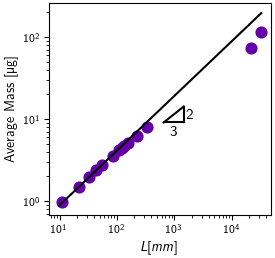

In [36]:
configureLatexPlot("halfbeamer", caption_spacer=0.8)
plt.figure()
L = [11, 22,34,58,111, 111]
# print(l_every_normal_dt_dict[2]["29.25"].items())
for k, r in l_myprobs_every_normal_dict[2]["29.25"].items():
    # if int(k) < 400:
    avg_mass = np.mean(r.m)
    plt.scatter(int(k), avg_mass*1e9, label=r.label+"mm", s = 60, color="#6400a7")
plt.xlabel("$L [mm]$")
plt.ylabel("Average Mass [µg]")
x = np.linspace(10, 33000, 100)
# plt.plot(x, x/25)
plt.plot(x, (x/12)**(2/3), color = "k")

# x_start = 12 
# x_end   = 20 
# y_start = (x_start/12)**(2/3)
# y_end   = (x_end/12)**(2/3)  
# plt.plot([x_start, x_end], [y_start, y_start], color="k", lw=1) # Horizontal
# plt.plot([x_end, x_end], [y_start, y_end], color="k", lw=1)     # Vertical
# plt.text(np.sqrt(x_start * x_end), y_start * 0.92, "3", ha='center', va='top', fontsize=10)
# plt.text(x_end * 1.05, np.sqrt(y_start * y_end), "2", ha='left', va='center', fontsize=10)

ax = plt.gca() # Get current axes
axins = ax.inset_axes([0.5, 0.40, 0.15, 0.15]) 
axins.plot([0, 3], [0, 0], color='black', lw=1.5)  # Run
axins.plot([3, 3], [0, 2], color='black', lw=1.5)  # Rise
axins.plot([0, 3], [0, 2], color='black', lw=1.5)  # Hypotenuse
axins.text(1.5, -0.3, "3", ha='center', va='top', fontsize=11)
axins.text(3.3, 1.0, "2", ha='left', va='center', fontsize=11)
axins.set_xlim(-0.5, 4.5)
axins.set_ylim(-1, 3)
axins.axis('off')

plt.xscale('log')
plt.yscale('log')
# plt.legend()
# plt.grid()
plt.savefig(figure_dir+"mass_avgs.pdf")
# plt.xlim([1e-3, 2e-2])
# plt.ylim([1, 10])